# Big Data Analytics
Praktikum Sommersemester 2023. <small>Version 1.0</small>

# Aufgabe 4: DataFrames 

### Arbeitsanweisung

Bereiten Sie Ihr Wissen über Dataframes mit pandas auf und arbeiten Sie mit dem Datensatz Iris. Platzieren Sie Ihre Lösungen in den vorgegeben Zellen, so dass der darin ausgeführte Code die geforderte Ausgabe produziert. Liefern Sie auch aussagekräftiges Markdown den Aufgaben.

----
Für diese Aufgabe stehen die folgenden Dateien in der JupyterLab-Umgebung zur Verfügung:

* `Big_Data_Analytics_1/datasets/iris/*`<br>Iris-Datensatz

## Aufgabe 4

1. Erarbeiten Sie sich das nötige Wissen zum Einlesen von Daten in einen `pandas Dataframe` (z.B. aus „Python for Data Analysis“ (bzw. der deutschen Ausgabe)).

2. Laden sie den Iris-Datensatz in einen Dataframe und geben Sie grundlegende Statistiken zu den Daten aus (wie geht das einfach mit einem Dataframe?).

3. Visualisieren Sie den Datensatz
    1.  Als Scattermatrix (mittels des python Paketes `matplotlib`)
    2.  Als Boxplots für die einzelnen Spalte des Datensatzes


4. Welche Schlüsse können Sie aus den Daten und deren Visualisierungen hinsichtlich einer möglichen Klassifikation der Daten ziehen?

## Durchführung Aufgabe 4 2

Zu beginn inkludieren wir die benötigten Bibliotheken `pandas` und `matplotlib` um die Aufgaben lösen zu können.

Dann lesen wir den Iris_Datensatz `data.all` mit der `read_csv`-Funktion() in einen `pandas` Dataframe `df`. Der Parameter `header=None` gibt an, dass die eingelesene Datei keine Kopfzeile enthält. Dies bedeutet, dass die erste Zeile der Daten als Datenzeile behandelt wird und nicht als Spaltenamen.

Danach teile ich die erste Spalte des DataFrames `df` anhand der Leerzeichen und erzeuge eine Liste von Werten. 
Das `expand=True`-Argument erweitert die geteilten Werte in separate Spalten. 
Der resultierende DataFrame `data_all` enthält diese geteilten Werte in separaten Spalten, wobei die Anzahl der Spalten der Anzahl der geteilten Werte entspricht. 
Die Spaltennamen werden als `['sl', 'sw', 'pl', 'pw', 'class']` festgelegt, um die Bedeutung jeder Spalte anzugeben.

Die Spalten `['sl', 'sw', 'pl', 'pw']` werden mit der `astype(float)`-Funktion zu float64 konvertiert.

Zum Schluss werden die grundlegenden Statistiken ausgegeben.

### Quellen:

* https://pandas.pydata.org/docs/getting_started/intro_tutorials/02_read_write.html
* https://sparkbyexamples.com/pandas/pandas-convert-string-to-float-type-dataframe/
* https://pandas.pydata.org/docs/getting_started/intro_tutorials/01_table_oriented.html
* https://pandas.pydata.org/docs/getting_started/intro_tutorials/02_read_write.html

In [1]:
# Aufgabe 4 2
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../Big_Data_Analytics_1/datasets/iris/data.all", header=None)

data_all = df[0].str.split(" ", expand=True)

data_all.columns = ['sl', 'sw', 'pl', 'pw', 'class']

data_all = data_all.astype({'sl':'float','sw':'float','pl':'float','pw':'float'})

print(data_all.describe())
print()
print(data_all.info())
print()
print(data_all)


               sl          sw          pl          pw
count  150.000000  150.000000  150.000000  150.000000
mean     5.843333    3.057333    3.758000    1.199333
std      0.828066    0.435866    1.765298    0.762238
min      4.300000    2.000000    1.000000    0.100000
25%      5.100000    2.800000    1.600000    0.300000
50%      5.800000    3.000000    4.350000    1.300000
75%      6.400000    3.300000    5.100000    1.800000
max      7.900000    4.400000    6.900000    2.500000

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sl      150 non-null    float64
 1   sw      150 non-null    float64
 2   pl      150 non-null    float64
 3   pw      150 non-null    float64
 4   class   150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

      sl   sw   pl   pw           class
0    5.1  3.5  1.4  0.2     Iris-setosa
1    4.9  3.

## Durchführung Aufgabe 4 3A

Mit `pandas.plotting.scatter_matrix` plotte ich über die Spalten `['sl', 'sw', 'pl', 'pw']` die Scattermatrix.

### Quellen:

* https://pandas.pydata.org/docs/reference/api/pandas.plotting.scatter_matrix.html

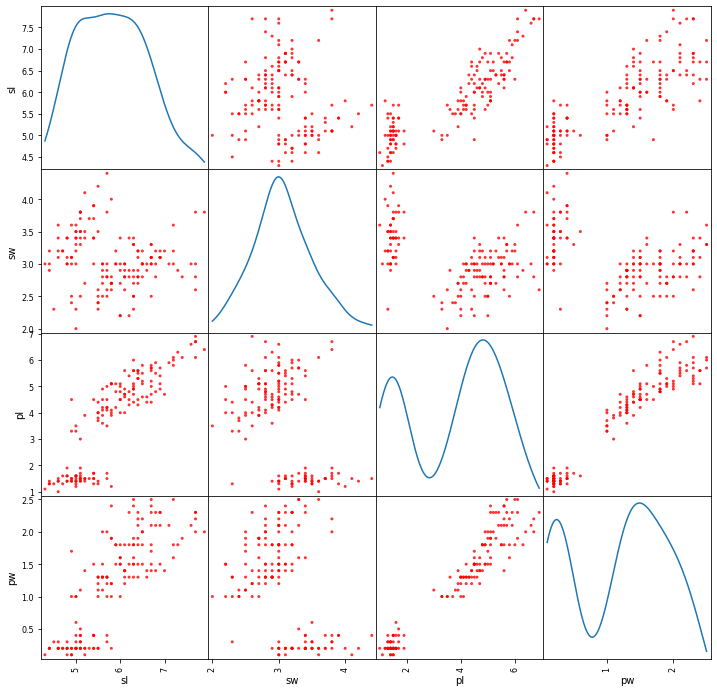

In [2]:
# Aufgabe 4 3A

pd.plotting.scatter_matrix(data_all[['sl', 'sw', 'pl', 'pw']], alpha=0.8, figsize=(12, 12), diagonal='kde', color="r")
plt.show()

## Durchführung Aufgabe 4 3B

Mit `pandas.plotting.boxplot` plotte ich über die Spalten `['sl', 'sw', 'pl', 'pw']` den Boxplot.

### Quellen:

* https://pandas.pydata.org/docs/reference/api/pandas.plotting.boxplot.html

<AxesSubplot:>

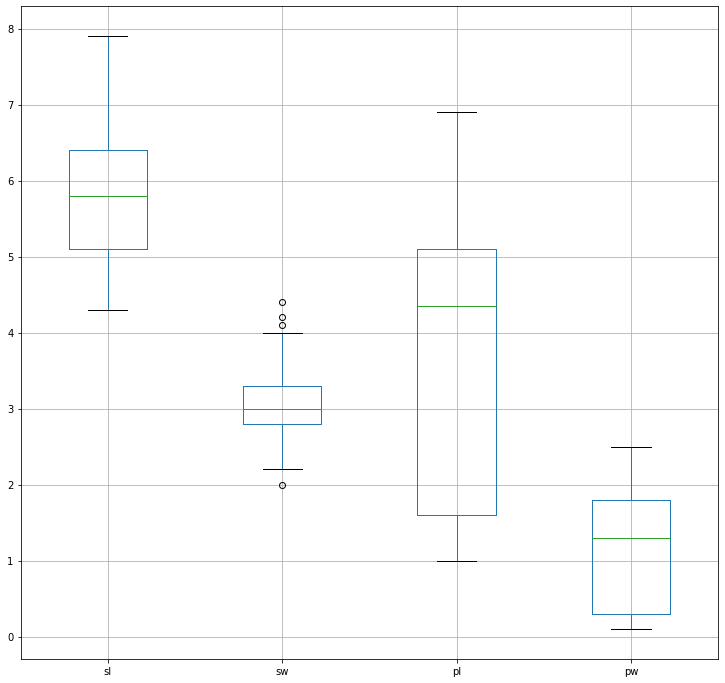

In [3]:
# Aufgabe 4 3B

data_all.boxplot(column=['sl', 'sw', 'pl', 'pw'], figsize=(12.5, 12))

## Antwort Aufgabe 4 4

Hinsichtlich der Klassifikation der Daten kann man sich in den Visualisierungen mehrere Faktoren angucken, die zur Klassifizierbarkeit der Daten beitragen. 

In der Boxplot Visualisierung erkennt man beim Merkmal `sw` Ausreißer. Diese Ausreißer könnten auf eine ungewöhnliche Datenverteilung hinweisen, die bei der Klassifikation der Daten berücksichtigt werden sollte.

Zusätzlich kann man in der Scatter-Matrix Korrelationen zwischen Merkmalen erkennen. Die Merkmale `pw` und `pl` und die Merkmale `pl` und `sl` korrelieren miteinander und weisen eine lineare Beziehung auf. Hierbei handelt es sich um eine positive Korrelation, weil die Werte sich tendenziell zusammen erhöhen. Für die Klassifikation der Daten kann es redundant sein, alle korrelierten Merkmale zu verwenden. 

Anhand der Visualisierung im Boxplot sieht man, dass die Daten unterschiedlich verteilt sind. Dies erkennt man, da die Boxen unterschiedlich verteilt sind, mit jeweils unterschiedlichen Medianwerte. Aufgrund der höheren Lage des Median zu den Merkmalen `pl` und `pw` kann man darauf schließen, dass die Verteilung der Datenpunkte linksschief gerichtet ist und bei den Merkmalen `sl` und `sw` aufgrund der mittigen Lage des Median, symmetrisch verteilt sind. Dies kann darauf hindeuten, dass die Daten klassifizierbar sind, da sie Hinweise auf unterschiedliche Eigenschaften und Mustern liefern.

Als Letztes erkenne ich in der Scattermatrix, dass die Datenpunkte in den verschiedenen Subplots an bestimmten Stellen konzentriert sind, da sie Cluster bilden. Dies erkennt man besonders in dem Subplot, wo die Datenpunkte zu der Beziehung der Merkmale `pw` und `pl` visualisiert sind. Durch die Clusterbildung könnte man die Klassifikation der Daten in verschiedene Kategorien oder Klassen ermöglichen.